C:\Users\ygunj\AppData\Local\Temp\ipykernel_18244\3914606588.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


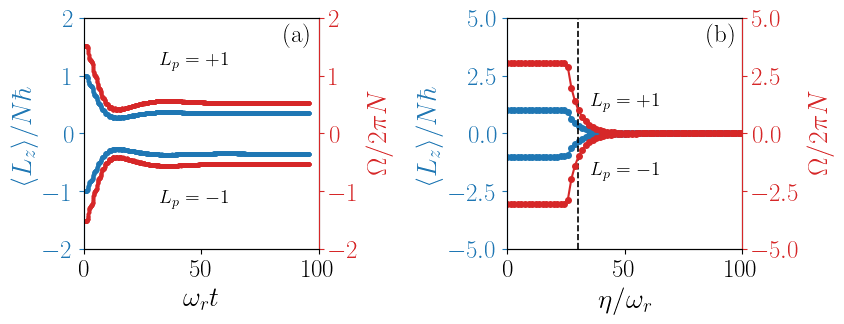

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# LOAD DATA
# ==================================================
data = np.load(r"Figure5_data.npz")

t_plus  = data['t_plus']
t_minus = data['t_minus']

Lz_plus_t  = data['Lz_plus_t']
Lz_minus_t = data['Lz_minus_t']

Omega_plus_t  = data['Omega_plus_t']
Omega_minus_t = data['Omega_minus_t']

eta_vals = data['eta_vals']

Lz_plus  = data['Lz_plus']
Lz_minus = data['Lz_minus']

Omega_plus  = data['Omega_plus']
Omega_minus = data['Omega_minus']

omega_r = data['omega_r']
hbar    = data['hbar']

# ==================================================
# STYLE
# ==================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 13,
})

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3), gridspec_kw={'wspace': 0.8})

def add_label(ax, label):
    ax.text(0.85, 0.98, label, transform=ax.transAxes,
            fontsize=18, va='top', ha='left')

# ==================================================
# (a) TIME DYNAMICS
# ==================================================
axL = axes[0]
axR = axL.twinx()

axL.plot(t_plus * omega_r, Lz_plus_t/hbar, 'o-', markersize=2, color='tab:blue')
axL.plot(t_minus * omega_r, Lz_minus_t/hbar, 'o-', markersize=2, color='tab:blue')

axR.plot(t_plus * omega_r, Omega_plus_t/(2*np.pi), 'o-', markersize=2, color='tab:red')
axR.plot(t_minus * omega_r, Omega_minus_t/(2*np.pi), 'o-', markersize=2, color='tab:red')

axL.set_xlabel(r'$\omega_r t$')
axL.set_ylabel(r'$\langle L_z\rangle/N\hbar$', color='tab:blue')
axR.set_ylabel(r'$\Omega/2\pi N$', color='tab:red')

axL.tick_params(axis='y', colors='tab:blue')
axR.tick_params(axis='y', colors='tab:red')

axL.spines['left'].set_color('tab:blue')
axR.spines['right'].set_color('tab:red')

axL.set_xlim([0, 100])
axL.set_ylim([-2, 2])
axR.set_ylim([-2, 2])

axL.text(32, 1.2*np.max(Lz_plus_t/hbar), r'$L_p=+1$', fontsize=14)
axL.text(32, -1.2*np.max(Lz_plus_t/hbar), r'$L_p=-1$', fontsize=14)

add_label(axL, '(a)')

# ==================================================
# (b) STEADY STATE
# ==================================================
axL2 = axes[1]
axR2 = axL2.twinx()

axL2.plot(eta_vals/omega_r, Lz_plus/hbar, 'o-', markersize=4, color='tab:blue')
axL2.plot(eta_vals/omega_r, Lz_minus/hbar, 'o-', markersize=4, color='tab:blue')

axR2.plot(eta_vals/omega_r, Omega_plus/(2*np.pi), 'o-', markersize=4, color='tab:red')
axR2.plot(eta_vals/omega_r, Omega_minus/(2*np.pi), 'o-', markersize=4, color='tab:red')

axL2.axvline(x=30, color='k', ls='--', lw=1.2)

axL2.set_xlabel(r'$\eta/\omega_r$')
axL2.set_ylabel(r'$\langle L_z\rangle/N\hbar$', color='tab:blue')
axR2.set_ylabel(r'$\Omega/2\pi N$', color='tab:red')

axL2.tick_params(axis='y', colors='tab:blue')
axR2.tick_params(axis='y', colors='tab:red')

axL2.spines['left'].set_color('tab:blue')
axR2.spines['right'].set_color('tab:red')

axL2.set_xlim([0, 100])
axL2.set_ylim([-5, 5])
axR2.set_ylim([-5, 5])

axL2.text(35, 1.2*np.max(Lz_plus/hbar), r'$L_p=+1$', fontsize=14)
axL2.text(35, -1.8*np.max(Lz_plus/hbar), r'$L_p=-1$', fontsize=14)

add_label(axL2, '(b)')

# ==================================================
# SHOW
# ==================================================
plt.tight_layout()
plt.show()